# Influence of quadratic damping on the MPM

This notebook:
1. Reads **multiple input/result file pairs** (the original 16-case batch plus the extra "extreme" seastate, cases 17-20).
2. Merges them into one long-format **CSV** (`merged_quadinfluence.csv`).
3. Analyses the influence of the quadratic damping coefficients on the **mean-compensated MPM** of Z, pitch and roll.

**Mean compensation:** the analysed quantity is the *dynamic* amplitude `MPM_dyn = MPM - mean`, i.e. the MPM measured relative to the static offset (drift/trim/mean heel). The mean is a static component that does not belong to the dynamic damping response, so it is subtracted out.

**File structure** (verified on the supplied files):
- Results are stored **per case in horizontal blocks of 9 columns**: `mean Z, mean pitch, mean roll, MPM Z, MPM pitch, MPM roll, std Z, std pitch, std roll`.
- The input-result link is **positional within each file pair**: block *i* belongs to input row *i* of the same pair.
- In the results, **mean and std are on the first data row** and the **MPM values are on the second data row**; the cells under the MPM columns on the first row only contain the label `"MPM"`. Header casing is matched case-insensitively.


## 1. Imports and file pairs

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Each entry is an (input_xlsx, results_xlsx) pair. Add more pairs here to
# include more batches/seastates - they are merged in this order.
FILE_PAIRS = [
    (Path("Input_quadratic_influence.xlsx"),         Path("Results_quadinfluence.xlsx")),
    (Path("Input_quadratic_influence_extreme.xlsx"), Path("Results_quadinfluence_extreme.xlsx")),
]

OUTPUT_CSV = Path("merged_quadinfluence.csv")

# DOFs and metrics expected per block
DOFS    = ["Z", "pitch", "roll"]
METRICS = ["Mean", "MPM", "std"]
BLOCK_SIZE = len(DOFS) * len(METRICS)   # 9 columns per case

# Order of the damping cases (increasing quadratic damping)
DAMP_ORDER = ["nodamp", "lowdamp", "middamp", "highdamp"]


## 2. Helper functions (read input, unfold results)
These are applied to every file pair so adding a seastate is just adding a pair above.

In [39]:
def read_input(path):
    """Read one input file and add helper columns."""
    df = pd.read_excel(path, sheet_name=0)
    df.columns = [c.lstrip("%").strip() for c in df.columns]
    df["damp_case"] = df["Damp_Heave"].astype(str).str.strip().str.lower()
    # Case number: read from the filename (Case_017_...) so numbering is preserved
    df["case_id"] = (df["filename"].astype(str)
                     .str.extract(r"Case_(\d+)", expand=False).astype(int))
    df["seastate"] = ("Hs" + df["Hs"].astype(str)
                      + "_Tp" + df["Tp"].astype(str)
                      + "_dir" + df["Direction"].astype(str))
    return df


def unfold_results(path):
    """Unfold one horizontally-blocked results file into one row per case."""
    raw = pd.read_excel(path, sheet_name=0, header=None)
    n_cols = raw.shape[1]
    if n_cols % BLOCK_SIZE != 0:
        print(f"WARNING: {path.name}: column count {n_cols} is not a multiple "
              f"of {BLOCK_SIZE} - check the block structure.")
    n_blocks = n_cols // BLOCK_SIZE

    header_row = raw.iloc[0].tolist()
    data_row   = raw.iloc[1]   # mean + std live here
    mpm_row    = raw.iloc[2]   # MPM values live here

    def block_label(col_idx):
        h = str(header_row[col_idx]).strip()
        for m in METRICS:
            if h.lower().startswith(m.lower()):     # case-insensitive header match
                return m, h[len(m):].strip()
        return None, None

    records = []
    for b in range(n_blocks):
        base = b * BLOCK_SIZE
        rec = {}
        for k in range(BLOCK_SIZE):
            metric, dof = block_label(base + k)
            if metric is None:
                continue
            val = mpm_row.iloc[base + k] if metric == "MPM" else data_row.iloc[base + k]
            rec[f"{metric}_{dof}"] = pd.to_numeric(val, errors="coerce")
        records.append(rec)
    return pd.DataFrame(records)


## 3. Read, merge and write CSV
Each pair is merged positionally on its own, then all pairs are concatenated. A warning is printed (not an error) if row counts within a pair do not match.

In [40]:
parts = []
for inp_path, res_path in FILE_PAIRS:
    inp = read_input(inp_path)
    res = unfold_results(res_path)

    if len(res) != len(inp):
        print(f"WARNING: {inp_path.name} has {len(inp)} input rows but "
              f"{res_path.name} has {len(res)} result blocks - positional link "
              "may be wrong for this pair!")

    n = min(len(inp), len(res))
    part = pd.concat([inp.iloc[:n].reset_index(drop=True),
                      res.iloc[:n].reset_index(drop=True)], axis=1)
    parts.append(part)
    print(f"{inp_path.name:48s} -> {n} cases merged")

merged = pd.concat(parts, ignore_index=True).sort_values("case_id").reset_index(drop=True)
merged["damp_case"] = pd.Categorical(merged["damp_case"], categories=DAMP_ORDER, ordered=True)

merged.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved: {OUTPUT_CSV.resolve()}  ({merged.shape[0]} rows x {merged.shape[1]} cols)")
print("Cases:", merged['case_id'].min(), "-", merged['case_id'].max(),
      "| seastates:", merged['seastate'].nunique())
merged.head()


Input_quadratic_influence.xlsx                   -> 16 cases merged
Input_quadratic_influence_extreme.xlsx           -> 4 cases merged

Saved: C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulaties_redo\merged_quadinfluence.csv  (20 rows x 26 cols)
Cases: 1 - 20 | seastates: 5


,filename,Hs,Tp,Tz,Direction,Damp_Heave,Damp_Roll,Damp_Pitch,Lin_Heave,Quad_Heave,...,seastate,Mean_Z,Mean_pitch,Mean_roll,MPM_Z,MPM_pitch,MPM_roll,std_Z,std_pitch,std_roll
0,ymlfiles\Case_001_H1_T4_dir0_nodamp.yml,1,4,3.1008,0,nodamp,nodamp,nodamp,1,0.0,...,Hs1_Tp4_dir0,-0.156056,0.686706,-0.002337,-0.038499,3.684554,-0.001910,0.029872,0.751857,0.000112
1,ymlfiles\Case_002_H1_T4_dir0_lowdamp.yml,1,4,3.1008,0,lowdamp,lowdamp,lowdamp,1,1.0,...,Hs1_Tp4_dir0,-0.156056,0.686698,-0.002337,-0.038586,3.684023,-0.001910,0.029850,0.751726,0.000112
2,ymlfiles\Case_003_H1_T4_dir0_middamp.yml,1,4,3.1008,0,middamp,middamp,middamp,1,2.5,...,Hs1_Tp4_dir0,-0.156056,0.686671,-0.002337,-0.038693,3.682238,-0.001910,0.029823,0.751302,0.000112
3,ymlfiles\Case_004_H1_T4_dir0_highdamp.yml,1,4,3.1008,0,highdamp,highdamp,highdamp,1,4.0,...,Hs1_Tp4_dir0,-0.156055,0.686652,-0.002337,-0.038806,3.681041,-0.001910,0.029792,0.751006,0.000112
4,ymlfiles\Case_005_H2_T8_dir180_nodamp.yml,2,8,6.2016,180,nodamp,nodamp,nodamp,1,0.0,...,Hs2_Tp8_dir180,-0.156897,0.649187,-0.002357,1.624775,13.266698,-0.001006,0.467083,3.305794,0.000354


## 4. Mean-compensated MPM

We define the dynamic MPM as `MPM_dyn = MPM - mean` for each DOF, and use its absolute value for the comparison (the sign of an extreme excursion is not relevant).

Roll is excluded for head/following seas (direction 0 and 180 deg), where there is virtually no roll excitation.

In [41]:
# Plot styling: consistent, readable font sizes
plt.rcParams.update({
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "legend.title_fontsize": 11,
    "figure.titlesize": 17,
})

ROLL_EXCLUDE_DIRECTIONS = [0, 180]

# Mean-compensated (dynamic) MPM and its absolute value
for d in DOFS:
    merged[f"MPMdyn_{d}"]     = merged[f"MPM_{d}"] - merged[f"Mean_{d}"]
    merged[f"MPMdyn_{d}_abs"] = merged[f"MPMdyn_{d}"].abs()

# Mask out roll where it is not meaningful
roll_mask = merged["Direction"].isin(ROLL_EXCLUDE_DIRECTIONS)
merged.loc[roll_mask, "MPMdyn_roll_abs"] = np.nan

dyn_cols = [f"MPMdyn_{d}" for d in DOFS]
overview = (merged
    .sort_values(["case_id"])
    [["case_id", "seastate", "damp_case",
      "Quad_Heave", "Quad_Roll", "Quad_Pitch"] + dyn_cols])
overview


,case_id,seastate,damp_case,Quad_Heave,Quad_Roll,Quad_Pitch,MPMdyn_Z,MPMdyn_pitch,MPMdyn_roll
0,1,Hs1_Tp4_dir0,nodamp,0.0,0,0,0.117557,2.997847,0.000427
1,2,Hs1_Tp4_dir0,lowdamp,1.0,300,200,0.117470,2.997325,0.000427
2,3,Hs1_Tp4_dir0,middamp,2.5,800,850,0.117363,2.995567,0.000426
3,4,Hs1_Tp4_dir0,highdamp,4.0,1300,1300,0.117250,2.994389,0.000427
4,5,Hs2_Tp8_dir180,nodamp,0.0,0,0,1.781672,12.617511,0.001351
5,6,Hs2_Tp8_dir180,lowdamp,1.0,300,200,1.776041,12.550826,0.001545
6,7,Hs2_Tp8_dir180,middamp,2.5,800,850,1.768308,12.334735,0.001384
7,8,Hs2_Tp8_dir180,highdamp,4.0,1300,1300,1.760300,12.195249,0.001485
8,9,Hs4_Tp8_dir45,nodamp,0.0,0,0,2.821154,10.480245,17.142711
9,10,Hs4_Tp8_dir45,lowdamp,1.0,300,200,2.810550,10.450486,16.994341


### 4.1 Mean-compensated MPM per damping case, per seastate
One subplot per DOF; each line is a seastate, the x-axis is the (increasing) damping case. Roll only shows the directions where it is meaningful.

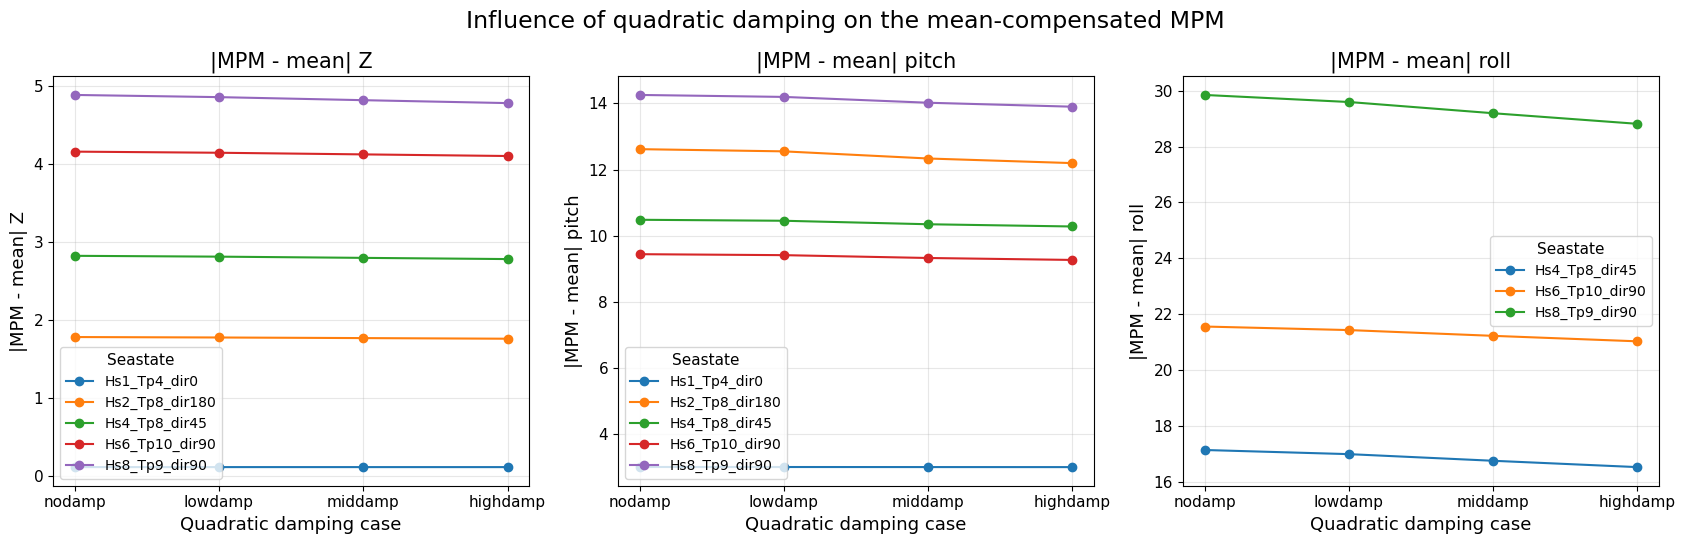

In [42]:
seastates = list(merged.sort_values("case_id")["seastate"].unique())

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharex=True)
for ax, dof in zip(axes, DOFS):
    for ss in seastates:
        sub = merged[merged["seastate"] == ss].sort_values("damp_case")
        y = sub[f"MPMdyn_{dof}_abs"]
        if y.notna().any():
            ax.plot(sub["damp_case"].astype(str), y, marker="o", label=ss)
    ax.set_title(f"|MPM - mean| {dof}")
    ax.set_xlabel("Quadratic damping case")
    ax.set_ylabel(f"|MPM - mean| {dof}")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Seastate")
fig.suptitle("Influence of quadratic damping on the mean-compensated MPM")
fig.tight_layout()
plt.show()


### 4.2 Relative reduction with respect to "nodamp"

For each seastate `nodamp` is the reference; the dynamic MPM is shown as a **reduction from that reference**, so the curves start at **0% at nodamp** and rise as the quadratic damping increases.

`reduction% = (1 - |MPM_dyn| / |MPM_dyn,nodamp|) * 100`

In [46]:
def reduction_from_nodamp(df, dof, ref_case="nodamp"):
    """Reduction of the mean-compensated |MPM| relative to ref_case, in percent."""
    out = {}
    for ss in seastates:
        sub = df[df["seastate"] == ss].set_index("damp_case").sort_index()
        if ref_case not in sub.index:
            continue
        ref = sub.loc[ref_case, f"MPMdyn_{dof}_abs"]
        if pd.isna(ref) or ref == 0:
            continue
        out[ss] = (1.0 - sub[f"MPMdyn_{dof}_abs"] / ref) * 100.0
    return pd.DataFrame(out)

for dof in DOFS:
    red = reduction_from_nodamp(merged, dof)
    print(f"\n=== {dof}: mean-compensated MPM reduction vs nodamp [%] ===")
    print(red.round(2).to_string() if not red.empty else "(no meaningful seastates)")



=== Z: mean-compensated MPM reduction vs nodamp [%] ===
           Hs1_Tp4_dir0  Hs2_Tp8_dir180  Hs4_Tp8_dir45  Hs6_Tp10_dir90  Hs8_Tp9_dir90
damp_case                                                                            
nodamp             0.00            0.00           0.00            0.00           0.00
lowdamp            0.07            0.32           0.38            0.35           0.57
middamp            0.17            0.75           0.93            0.85           1.37
highdamp           0.26            1.20           1.47            1.35           2.14

=== pitch: mean-compensated MPM reduction vs nodamp [%] ===
           Hs1_Tp4_dir0  Hs2_Tp8_dir180  Hs4_Tp8_dir45  Hs6_Tp10_dir90  Hs8_Tp9_dir90
damp_case                                                                            
nodamp             0.00            0.00           0.00            0.00           0.00
lowdamp            0.02            0.53           0.28            0.31           0.42
middamp            0.0

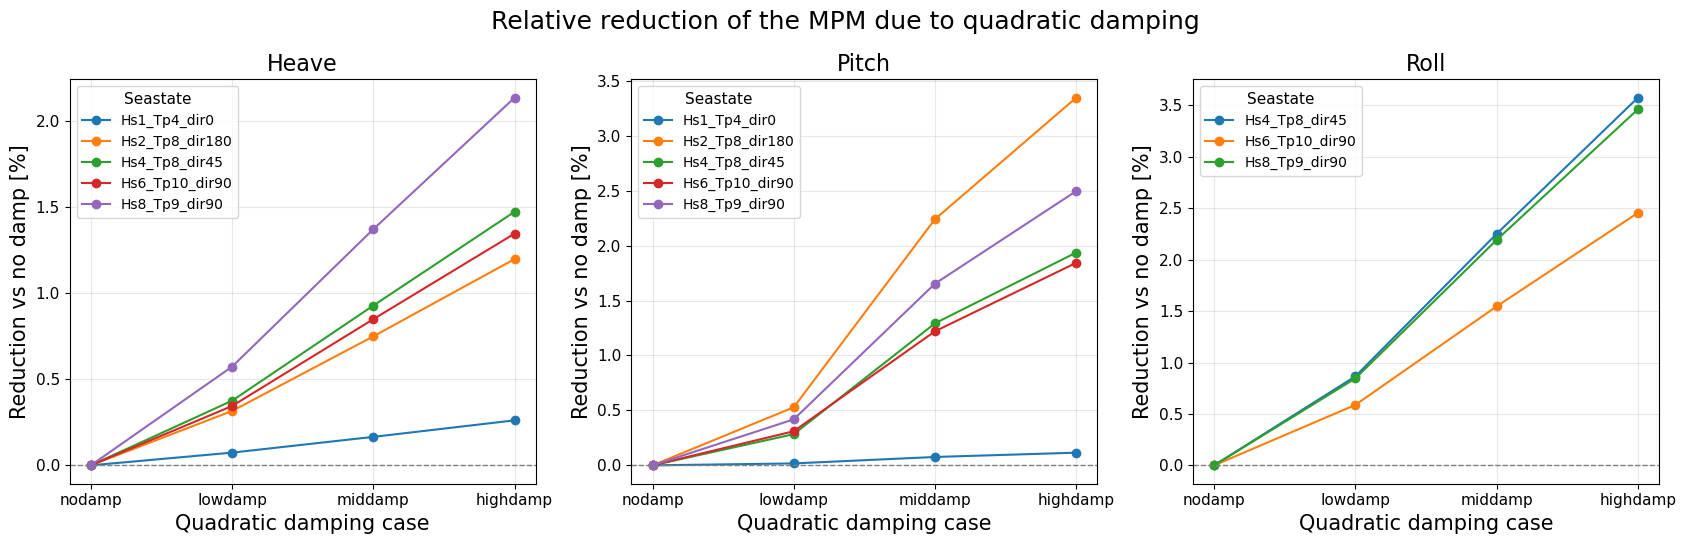

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharex=True)
for ax, dof in zip(axes, DOFS):
    red = reduction_from_nodamp(merged, dof)
    for ss in red.columns:
        ax.plot(red.index.astype(str), red[ss], marker="o", label=ss)
    ax.axhline(0, color="grey", ls="--", lw=1)     # zero (nodamp) reference
    
    if ax == axes[0]:    # only add ylabel to the first subplot for clarity
        ax.set_title(f"Heave"  , fontsize  = 16)
    if ax == axes[1]:
        ax.set_title(f"Pitch", fontsize  = 16   )
    if ax == axes[2]:
        ax.set_title(f"Roll", fontsize  = 16)
    ax.set_xlabel("Quadratic damping case", fontsize  = 15)
    ax.set_ylabel("Reduction vs no damp [%]" , fontsize  = 15)
    ax.grid(True, alpha=0.3)
    if red.shape[1] > 0:
        ax.legend(title="Seastate")
fig.suptitle("Relative reduction of the MPM due to quadratic damping", fontsize  = 18)
fig.tight_layout()
plt.show()


In [49]:
ROLL_EXCLUDE_DIRECTIONS = [0, 180]

def absolute_reduction_from_nodamp(df, dof):
    """Absolute reduction of |MPM| relative to the nodamp case (0 at nodamp)."""
    out = {}
    for ss in seastates:
        sub = df[df["seastate"] == ss].sort_values("damp_case").set_index("damp_case")

        # absolute MPM for this DOF
        mpm_abs = sub[f"MPM_{dof}"].abs()

        # exclude roll for head/following seas (0 / 180 deg)
        direction = sub["Direction"].iloc[0]
        if dof == "roll" and direction in ROLL_EXCLUDE_DIRECTIONS:
            continue

        ref = mpm_abs.loc["nodamp"]
        if pd.isna(ref):
            continue
        out[ss] = ref - mpm_abs        # absolute drop in MPM units
    return pd.DataFrame(out)

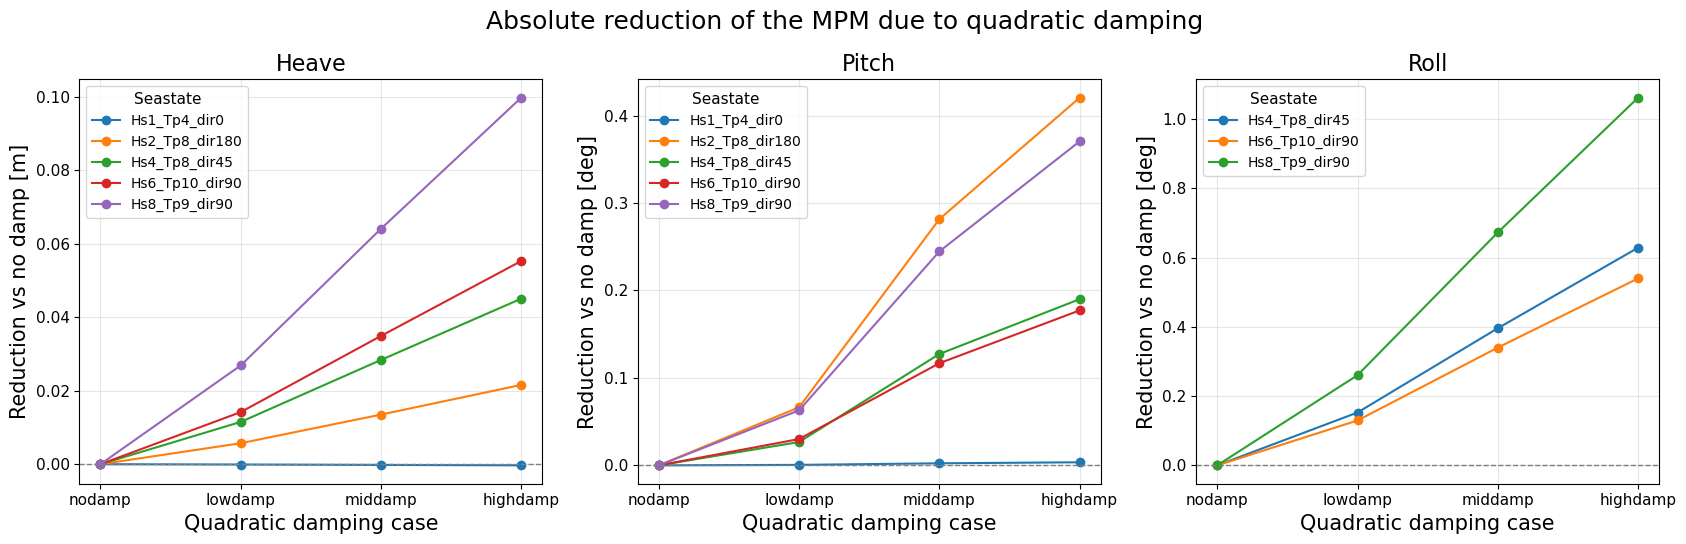

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharex=True)
for ax, dof in zip(axes, DOFS):
    red = absolute_reduction_from_nodamp(merged, dof)
    for ss in red.columns:
        ax.plot(red.index.astype(str), red[ss], marker="o", label=ss)
    ax.axhline(0, color="grey", ls="--", lw=1)     # zero (nodamp) reference

    if ax == axes[0]:
        ax.set_title("Heave", fontsize=16)
    if ax == axes[1]:
        ax.set_title("Pitch", fontsize=16)
    if ax == axes[2]:
        ax.set_title("Roll", fontsize=16)
    ax.set_xlabel("Quadratic damping case", fontsize=15)
    ax.set_ylabel(f"Reduction vs no damp [{DOF_UNITS[dof]}]", fontsize=15)
    ax.grid(True, alpha=0.3)
    if red.shape[1] > 0:
        ax.legend(title="Seastate")
fig.suptitle("Absolute reduction of the MPM due to quadratic damping", fontsize=18)
fig.tight_layout()
plt.show()

### 4.3 Summary: reduction per seastate and DOF

Percentage reduction of the mean-compensated MPM at the highest damping (`highdamp`) relative to `nodamp`. Empty cells mean the DOF is not analysed for that seastate (roll at 0 / 180 deg).

In [ ]:
summary = []
for dof in DOFS:
    red = reduction_from_nodamp(merged, dof)
    if "highdamp" in red.index:
        for ss in red.columns:
            summary.append({"DOF": dof, "seastate": ss,
                            "reduction_%": round(red.loc["highdamp", ss], 2)})
summary_df = (pd.DataFrame(summary)
              .pivot(index="seastate", columns="DOF", values="reduction_%"))
print("Reduction of mean-compensated |MPM| at highdamp vs nodamp [%]:")
summary_df


Reduction of mean-compensated |MPM| at highdamp vs nodamp [%]:


DOF,Z,pitch,roll
seastate,,,
Hs1_Tp4_dir0,0.26,0.12,NaN
Hs2_Tp8_dir180,1.20,3.35,NaN
Hs4_Tp8_dir45,1.47,1.94,3.58
Hs6_Tp10_dir90,1.35,1.84,2.46
Hs8_Tp9_dir90,2.14,2.50,3.46


### 4.4 Interpretation

- The analysed quantity is now the **dynamic** MPM (`MPM - mean`), so a constant offset (drift/trim/mean heel) no longer influences the comparison; only the wave-frequency response that the damping actually acts on is left.
- Roll responds most strongly to the quadratic damping (where it is analysed, 45 and 90 deg): the roll damping rises up to 1300 at `highdamp`, and roll is the DOF where the non-linear viscous damping matters most physically.
- The extra extreme seastate (Hs 8 / Tp 9 / dir 90, cases 17-20) is included automatically via the file-pair list; it has the largest absolute responses, so its dynamic MPM curves sit highest in the per-seastate plot.
- The effect on pitch and heave (Z) is smaller and seastate-dependent: where the response in a DOF is large, additional quadratic damping reduces the MPM most, because the damping force scales with the velocity squared.

> See the tables and figures above for the exact per-case values.